# Task 6: House Price Prediction

## Objective

The objective of this project is to predict house prices using property features such as area, bedrooms, bathrooms, parking, furnishing status, and location-related attributes.

A machine learning regression model is developed to estimate house prices and evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

**Dataset:** Housing.csv  
**Model:** Linear Regression  
**Environment:** Google Colab


## Cell 1: Install Required Libraries

Purpose: Install required machine learning libraries.

In [1]:
!pip install -q scikit-learn pandas matplotlib seaborn

## Cell 2: Import Libraries

Purpose: Import required packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Cell 3: Load Dataset

Purpose: Load the housing dataset.

In [3]:
df = pd.read_csv('/content/Housing.csv')

print(df.shape)
df.head()


(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Cell 4: Explore Dataset

Purpose: Understand dataset structure.

In [4]:
print(df.info())
print(df.isnull().sum())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom        

## Cell 5: View Columns

Purpose: Identify available features.

In [5]:
print(df.columns.tolist())


['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


## Cell 6: Encode Categorical Features

Purpose: Convert categorical values into numerical form.

In [6]:
categorical_cols = df.select_dtypes(include='object').columns

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## Cell 7: Feature Selection

Purpose: Separate features and target variable.

In [7]:
X = df.drop('price', axis=1)

y = df['price']

print(X.shape)
print(y.shape)


(545, 12)
(545,)


## Cell 8: Feature Scaling

Purpose: Normalize numerical features.

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


## Cell 9: Train Test Split

Purpose: Split data into training and testing sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)


(436, 12)
(109, 12)


## Cell 10: Train Regression Model

Purpose: Train Linear Regression model.

In [10]:
model = LinearRegression()

model.fit(X_train, y_train)

print('Model Training Completed')


Model Training Completed


## Cell 11: Make Predictions

Purpose: Predict house prices.

In [11]:
y_pred = model.predict(X_test)

print(y_pred[:5])


[5203691.70963177 7257004.02115475 3062828.59668172 4559591.65374424
 3332932.30559783]


## Cell 12: Evaluate Model

Purpose: Calculate MAE, RMSE and R² Score.

In [12]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print('MAE :', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)


MAE : 979679.6912959907
RMSE: 1331071.4167895124
R2 Score: 0.6494754192267793


## Cell 13: Actual vs Predicted Visualization

Purpose: Compare actual and predicted prices.

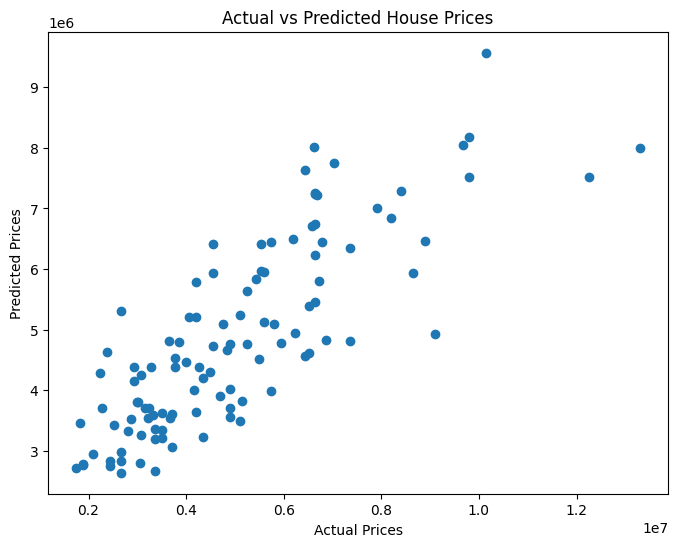

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted House Prices')

plt.show()


## Cell 14: Prediction Line Plot

Purpose: Visualize prediction performance.

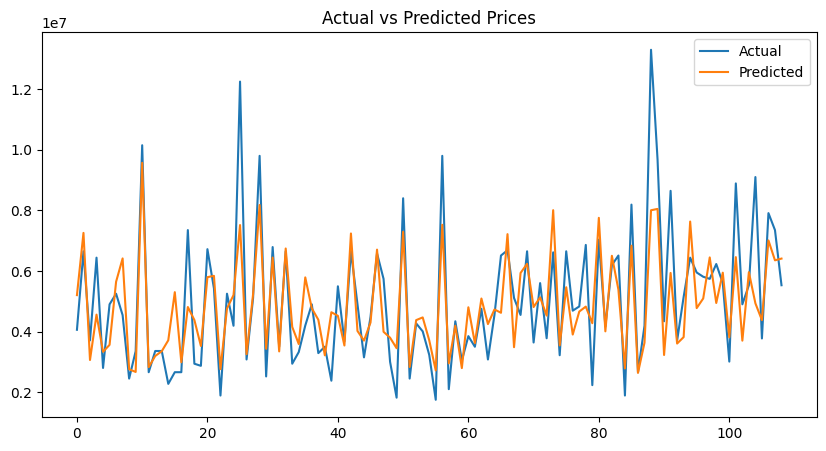

In [14]:
plt.figure(figsize=(10,5))

plt.plot(range(len(y_test)), y_test.values, label='Actual')

plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()

plt.title('Actual vs Predicted Prices')

plt.show()


## Cell 15: Feature Importance Analysis

Purpose: Examine impact of features.

In [15]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)


,Feature,Coefficient
2,bathrooms,550762.108735
0,area,511355.314864
8,airconditioning,365086.933939
3,stories,352072.086344
10,prefarea,267023.364350
9,parking,194330.065331
6,basement,187581.884388
7,hotwaterheating,143909.241493
4,mainroad,127770.253636
5,guestroom,89178.007942


## Result

The Linear Regression model was successfully trained on housing data and used to predict house prices.

The model learned relationships between house features such as area, bedrooms, bathrooms, parking, furnishing status, and final house price.


## Conclusion

A House Price Prediction system was successfully developed using Linear Regression.

Data preprocessing, feature encoding, feature scaling, model training, and evaluation were performed. The model was evaluated using MAE and RMSE metrics and visualized through actual versus predicted price comparisons.

This project demonstrates practical applications of regression modeling in real estate price estimation.
